# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
data = pd.read_csv('diabetes_dataset.csv')
data.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90


saya ingin drop semua kolom yang memiliki nilai boolean

In [3]:
bool_columns = [
    'race:AfricanAmerican', 
    'race:Asian', 
    'race:Caucasian', 
    'race:Hispanic', 
    'race:Other', 
    'hypertension', 
    'heart_disease'
]
data_dropped = data.drop(columns=bool_columns)
data_dropped.head()

,year,gender,age,location,smoking_history,bmi,hbA1c_level,blood_glucose_level
0,2020,Female,32.0,Alabama,never,27.32,5.0,100
1,2015,Female,29.0,Alabama,never,19.95,5.0,90
2,2015,Male,18.0,Alabama,never,23.76,4.8,160
3,2015,Male,41.0,Alabama,never,27.32,4.0,159
4,2016,Female,52.0,Alabama,never,23.75,6.5,90


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Jumlah baris dan kolom
print("Jumlah Baris dan Kolom:", data_dropped.shape)

# Informasi umum (termasuk missing values)
print("\nInformasi Dataset:")
data_dropped.info()

Jumlah Baris dan Kolom: (100000, 8)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 100000 non-null  int64  
 1   gender               100000 non-null  object 
 2   age                  100000 non-null  float64
 3   location             100000 non-null  object 
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   hbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 6.1+ MB


tidak ada missing value dan tipe data sepertinya sudah benar

In [5]:
print("Jumlah duplikasi: ", data_dropped.duplicated().sum())

Jumlah duplikasi:  94


nanti dibersihkan

In [6]:
# Statistik deskriptif untuk variabel numerik
print("Statistik Deskriptif:")
print(data_dropped.describe())

Statistik Deskriptif:
                year            age            bmi    hbA1c_level  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean     2018.360820      41.885856      27.320767       5.527507   
std         1.345239      22.516840       6.636783       1.070672   
min      2015.000000       0.080000      10.010000       3.500000   
25%      2019.000000      24.000000      23.630000       4.800000   
50%      2019.000000      43.000000      27.320000       5.800000   
75%      2019.000000      60.000000      29.580000       6.200000   
max      2022.000000      80.000000      95.690000       9.000000   

       blood_glucose_level  
count        100000.000000  
mean            138.058060  
std              40.708136  
min              80.000000  
25%             100.000000  
50%             140.000000  
75%             159.000000  
max             300.000000  


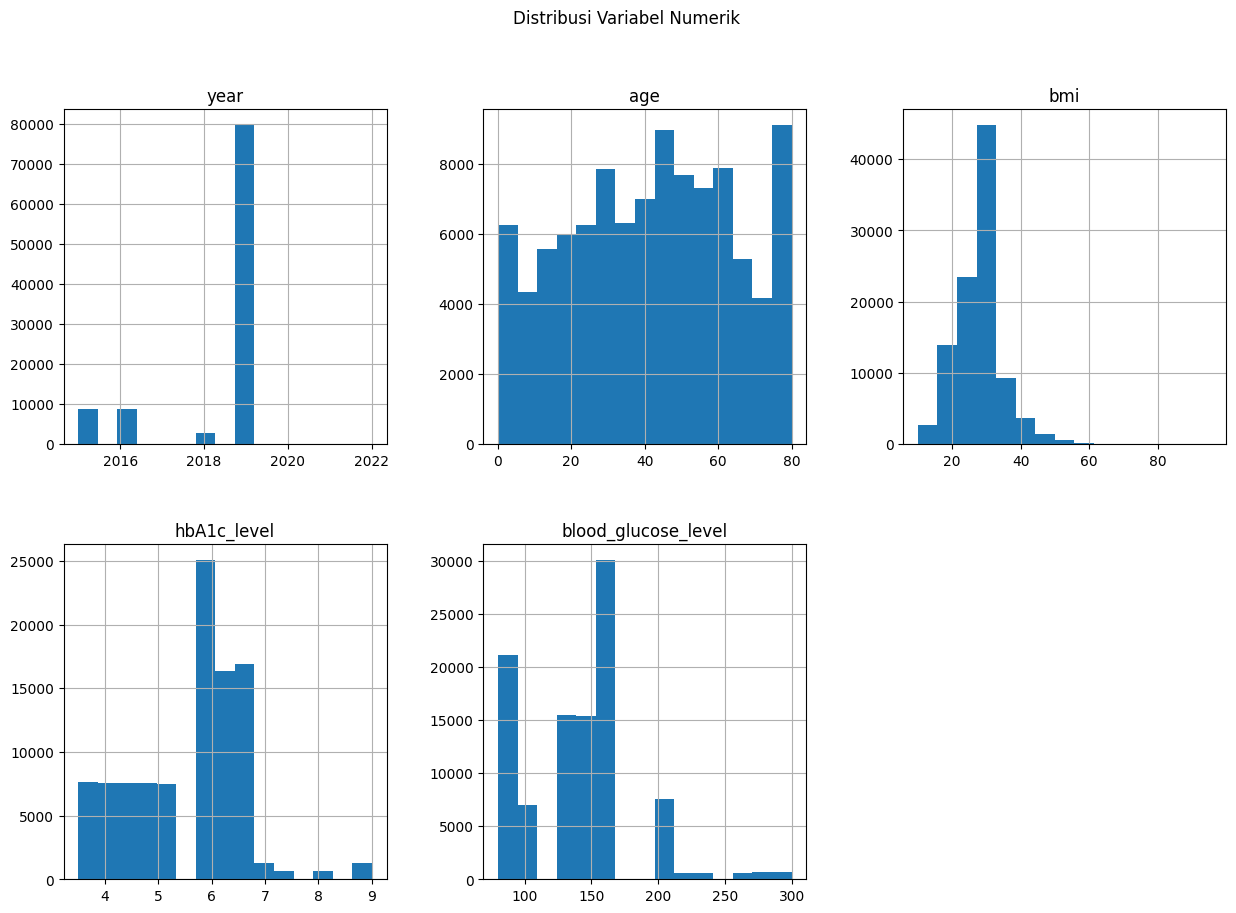

In [8]:
# Pilih kolom numerik
numerical_cols = ['year', 'age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

# Plot histogram
data_dropped[numerical_cols].hist(bins=15, figsize=(15, 10), layout=(2, 3))
plt.suptitle("Distribusi Variabel Numerik")
plt.show()

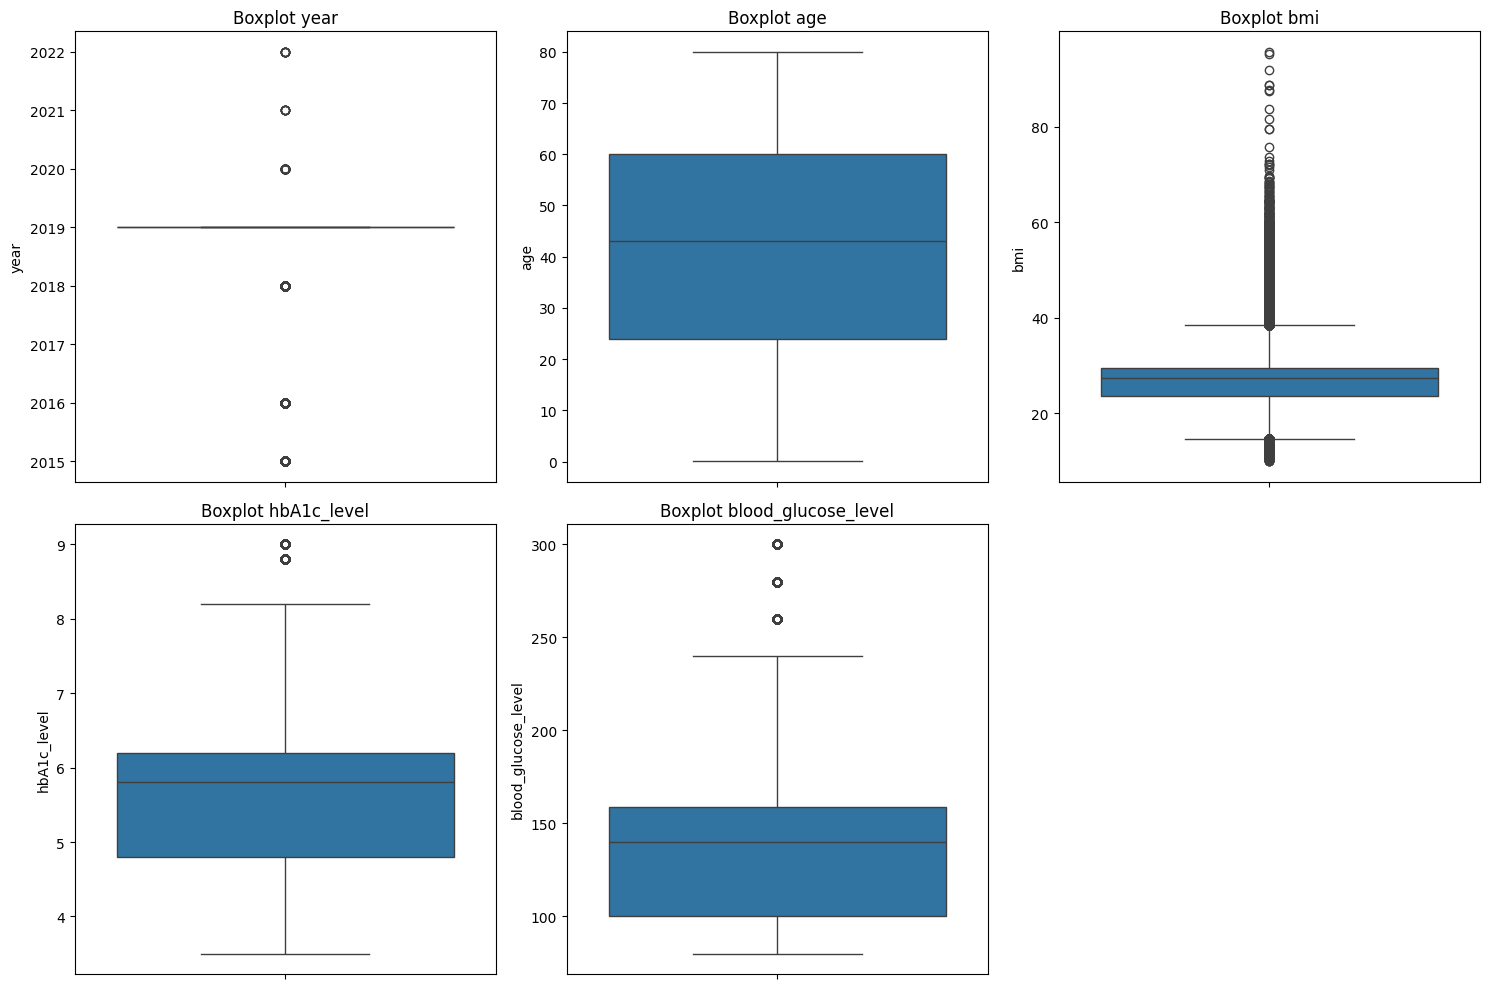

In [10]:
# Buat figure dengan subplot
plt.figure(figsize=(15, 10))

# Loop untuk tiap kolom
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)  # 2 baris, 3 kolom
    sns.boxplot(y=data[col])
    plt.title(f"Boxplot {col}")
    plt.ylabel(col)

# Atur layout agar tidak tumpang tindih
plt.tight_layout()
plt.show()

Saya plot scatter untuk fitur yang paling banyak outliernya

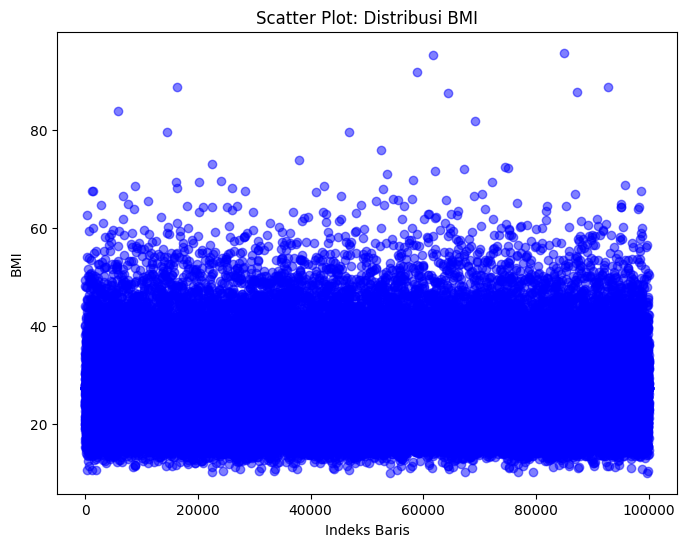

In [11]:
# Scatter plot: bmi vs indeks baris
plt.figure(figsize=(8, 6))
plt.scatter(range(len(data)), data_dropped['bmi'], color='blue', alpha=0.5)
plt.title('Scatter Plot: Distribusi BMI')
plt.xlabel('Indeks Baris')
plt.ylabel('BMI')
plt.show()

sepertinya year tidak penting, ini hanya berkaitan dengan waktu pengambilan data, kebanyakan pada tahun 2019 dan bisa dibilang itu masih cukup baru, jadi di sini saya ingin drop saja,
untuk outlier pada hba1c level dan blood glucose level hanya sedikit, menurut saya ini bisa didrop saja, data saya ada banyak (100000)
untuk outlier pada bmi mungkin bisa dicari alternatif lain nanti

In [7]:
data_dropped2=data_dropped.drop(columns='year')
data_dropped2.head()

,gender,age,location,smoking_history,bmi,hbA1c_level,blood_glucose_level
0,Female,32.0,Alabama,never,27.32,5.0,100
1,Female,29.0,Alabama,never,19.95,5.0,90
2,Male,18.0,Alabama,never,23.76,4.8,160
3,Male,41.0,Alabama,never,27.32,4.0,159
4,Female,52.0,Alabama,never,23.75,6.5,90


In [8]:
print("Jumlah duplikasi: ", data_dropped2.duplicated().sum())

Jumlah duplikasi:  143


setelah dihapus kolom year ternyata nambah duplikasinya dari 94 jadi 143

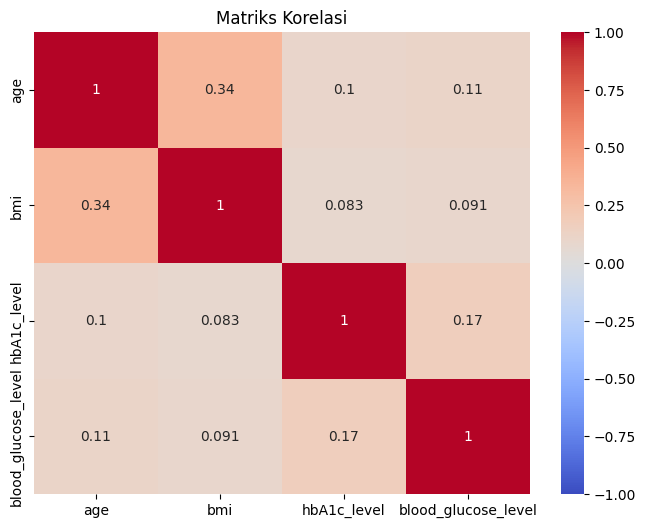

In [14]:
numerical_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
# Hitung korelasi antar variabel numerik
correlation_matrix = data_dropped2[numerical_cols].corr()

# Visualisasi heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriks Korelasi")
plt.show()

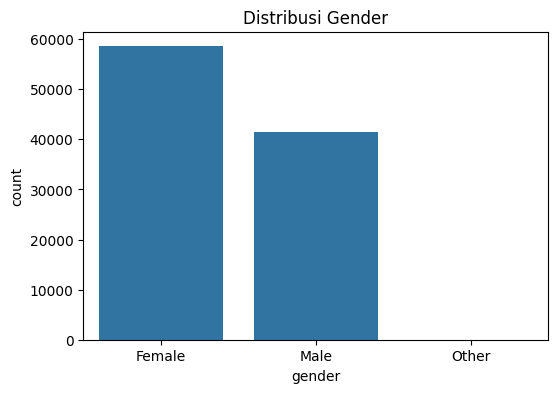

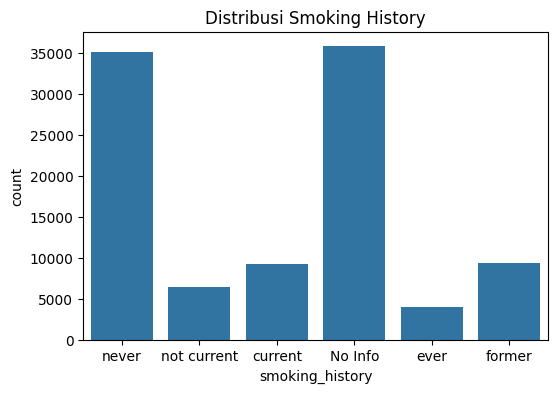

In [16]:
# Bar plot untuk gender
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=data_dropped2)
plt.title("Distribusi Gender")
plt.show()

# Bar plot untuk smoking_history
plt.figure(figsize=(6, 4))
sns.countplot(x='smoking_history', data=data_dropped2)
plt.title("Distribusi Smoking History")
plt.show()

saya kurang suka menggunakan data smoking history karena ada klasifikasi no info yang jumlahnya sangat banyak, jadi kurang bagus

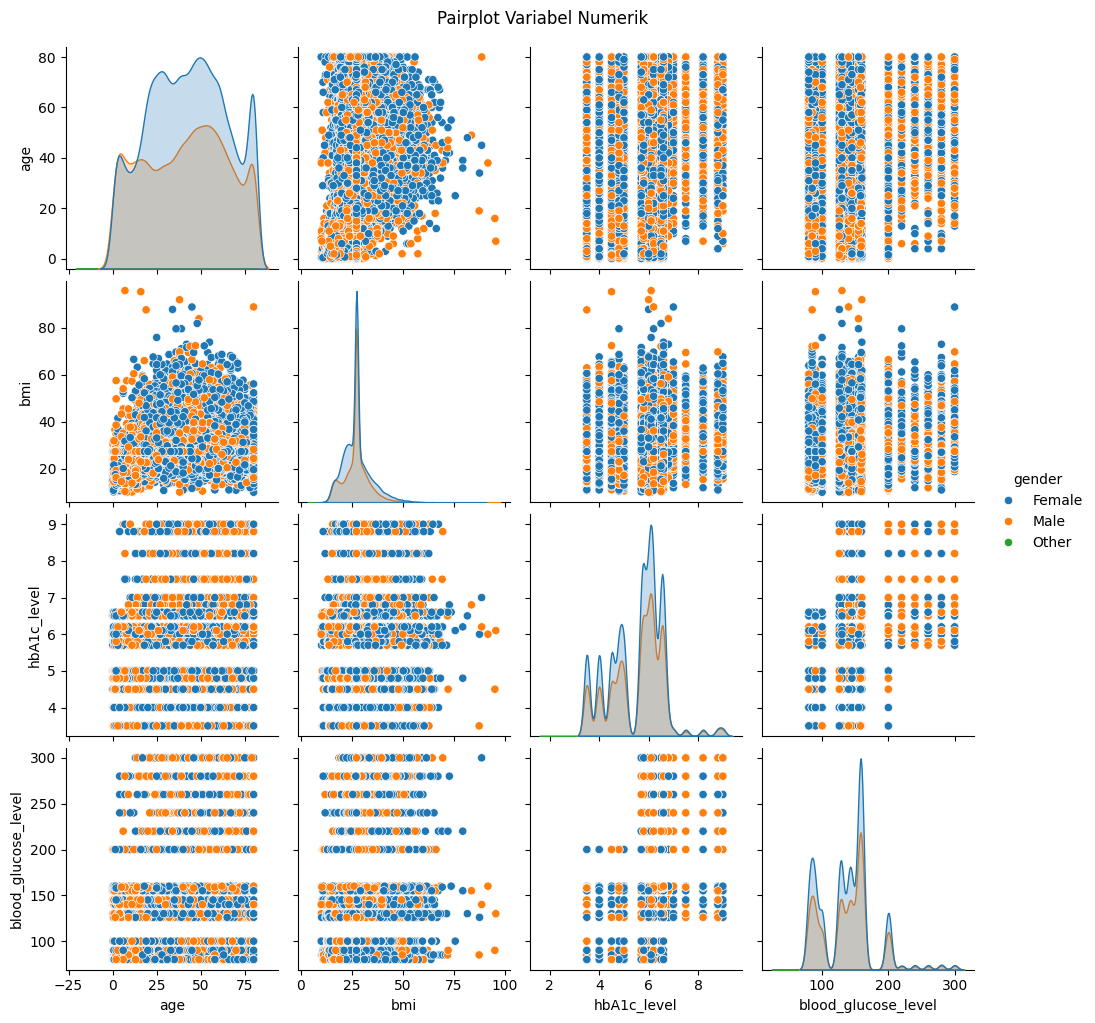

In [17]:
# Pairplot untuk variabel numerik dengan hue=gender
sns.pairplot(data, vars=numerical_cols, hue='gender')
plt.suptitle("Pairplot Variabel Numerik", y=1.02)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

data kosong tidak ada, 
menghapus data duplikat, tidak banyak sebenarnya tapi perlu dihapus

In [15]:
data_clean = data_dropped2.drop_duplicates()
print("Jumlah duplikasi: ", data_dropped2.duplicated().sum())
print("Jumlah duplikasi: ", data_clean.duplicated().sum())
print("Jumlah baris dan kolom: ", data_clean.shape)

Jumlah duplikasi:  143
Jumlah duplikasi:  0
Jumlah baris dan kolom:  (99857, 7)


Di sini saya ingin melakukan standarisasi (karena cocok untuk algoritma k-means) pada fitur penting yang ingin saya gunakan dalam proses clustering ini, yaitu age, bmi, hbA1c level, dan blood glucose level, dari heat map juga terlihat adanya korelasi antara ketiga fitur tersebut walau mungkin ada yang cukup lemah

In [21]:
# Pilih fitur untuk clustering
numeric_features = ['age', 'bmi', 'blood_glucose_level', 'hbA1c_level']
X = data_clean[numeric_features]

# Preprocessing: Standarisasi numerik, encode kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ])

# Terapkan preprocessing
X_scaled = preprocessor.fit_transform(X)

# Ubah ke DataFrame untuk inspeksi
all_cols = numeric_features
X_scaled_df = pd.DataFrame(X_scaled, columns=all_cols)

# Tampilkan 5 baris pertama
X_scaled_df.head()


,age,bmi,blood_glucose_level,hbA1c_level
0,-0.438444,-0.000116,-0.935040,-0.492966
1,-0.571723,-1.109805,-1.180648,-0.492966
2,-1.060410,-0.536139,0.538606,-0.679758
3,-0.038609,-0.000116,0.514045,-1.426928
4,0.450079,-0.537645,-1.180648,0.907978


In [18]:
X_scaled_df.shape

(99857, 4)

di sini saya mencoba lagi untuk melihat angka spesifik dari outlier, tapi untuk age tidak perlu karena box plot terlihat tidak ada outlier

In [22]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

bmi_outliers, bmi_lower, bmi_upper = detect_outliers(X_scaled_df, 'bmi')
print(f"Outlier pada bmi: {len(bmi_outliers)} baris")
print(f"Batas bawah bmi: {bmi_lower}, Batas atas bmi: {bmi_upper}")
print(bmi_outliers[['bmi']].head())

blood_outliers, blood_lower, blood_upper = detect_outliers(X_scaled_df, 'blood_glucose_level')
print(f"\nOutlier pada blood_glucose_level: {len(blood_outliers)} baris")
print(f"Batas bawah blood_glucose_level: {blood_lower}, Batas atas blood_glucose_level: {blood_upper}")
print(blood_outliers[['blood_glucose_level']].head())

# Deteksi outlier pada hbA1c_level
hba1c_outliers, hba1c_lower, hba1c_upper = detect_outliers(X_scaled_df, 'hbA1c_level')
print(f"\nOutlier pada hbA1c_level: {len(hba1c_outliers)} baris")
print(f"Batas bawah hbA1c_level: {hba1c_lower}, Batas atas hbA1c_level: {hba1c_upper}")
print(hba1c_outliers[['hbA1c_level']].head())


Outlier pada bmi: 6943 baris
Batas bawah bmi: -1.9078170662459883, Batas atas bmi: 1.6937786309999299
         bmi
14  3.304860
50  2.526422
53  1.934688
62  1.898552
67  3.122673

Outlier pada blood_glucose_level: 2038 baris
Batas bawah blood_glucose_level: -3.108668764752473, Batas atas blood_glucose_level: 2.687673968270629
     blood_glucose_level
112             3.485899
120             3.485899
127             2.994684
132             3.485899
297             3.977115

Outlier pada hbA1c_level: 1315 baris
Batas bawah hbA1c_level: -2.6410797652181897, Batas atas hbA1c_level: 2.5891107520469765
     hbA1c_level
29      3.056092
127     3.242885
132     3.242885
222     3.242885
301     3.242885


sebenarnya jumlah ini sangat kecil jika dibandingkan 100 rb dataset saya, tapi karena saya masih proses belajar, saya tidak ingin drop semuanya, untuk fitur bmi saya akan melakukan metode lain yaitu capping, sedangkan untuk blood glucose level dan hbA1c level saya gunakan dropping

Outlier pada bmi setelah capping: 0


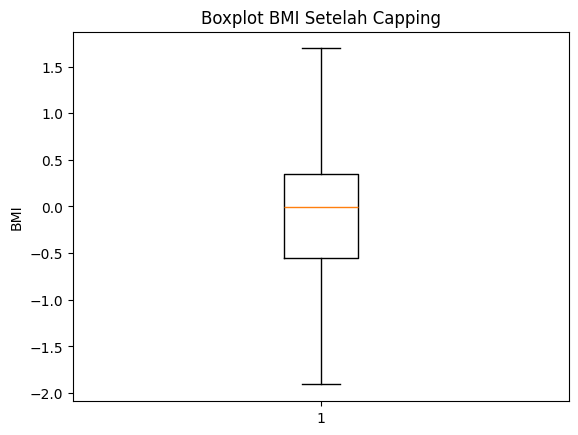

Jumlah baris sebelum drop: 99857
Jumlah baris setelah drop: 97819


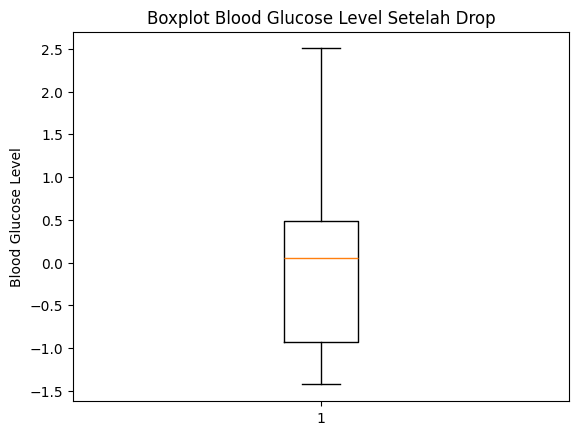

Jumlah baris sebelum drop: 98129
Jumlah baris setelah drop: 96814


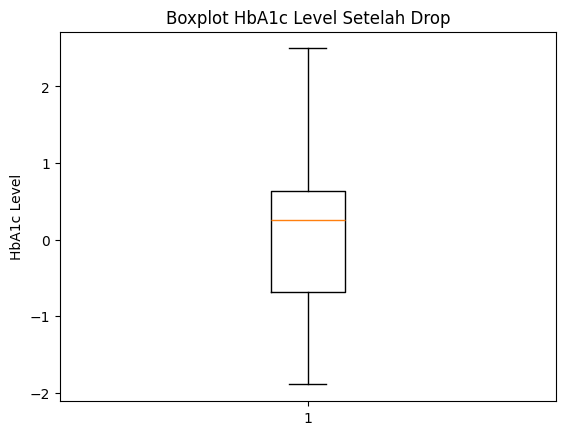

In [23]:
data_cleaned = X_scaled_df.copy()

data_cleaned['bmi'] = np.where(data_cleaned['bmi'] < bmi_lower, bmi_lower, data_cleaned['bmi'])
data_cleaned['bmi'] = np.where(data_cleaned['bmi'] > bmi_upper, bmi_upper, data_cleaned['bmi'])

# Cek apakah masih ada outlier setelah capping
bmi_outliers_after, _, _ = detect_outliers(data_cleaned, 'bmi')
print(f"Outlier pada bmi setelah capping: {len(bmi_outliers_after)}")

# Plot boxplot setelah capping
plt.boxplot(data_cleaned['bmi'])
plt.title('Boxplot BMI Setelah Capping')
plt.ylabel('BMI')
plt.show()

# Drop baris dengan outlier pada blood_glucose_level
data_cleaned = data_cleaned[(data_cleaned['blood_glucose_level'] >= blood_lower) & 
                            (data_cleaned['blood_glucose_level'] <= blood_upper)]

# Cek jumlah baris sebelum dan sesudah
print(f"Jumlah baris sebelum drop: {len(X_scaled_df)}")
print(f"Jumlah baris setelah drop: {len(data_cleaned)}")

# Plot boxplot setelah drop
plt.boxplot(data_cleaned['blood_glucose_level'])
plt.title('Boxplot Blood Glucose Level Setelah Drop')
plt.ylabel('Blood Glucose Level')
plt.show()

# Drop baris dengan outlier pada hbA1c_level
data_cleaned = data_cleaned[(data_cleaned['hbA1c_level'] >= hba1c_lower) & 
                            (data_cleaned['hbA1c_level'] <= hba1c_upper)]

# Cek jumlah baris sebelum dan sesudah
print(f"Jumlah baris sebelum drop: {len(data_cleaned) + len(hba1c_outliers)}")
print(f"Jumlah baris setelah drop: {len(data_cleaned)}")

# Plot boxplot setelah drop
plt.boxplot(data_cleaned['hbA1c_level'])
plt.title('Boxplot HbA1c Level Setelah Drop')
plt.ylabel('HbA1c Level')
plt.show()

Terlihat semua outlier sudah ditangani dengan baik dengan total data sebanyak 96814, untuk encode dan binning tidak dilakukan karena tidak cocok dengan algoritma yang akan digunakan (k-means) dan saya tidak memakai fitur kategorikal

In [25]:
print(f"jumlah duplikasi: {data_cleaned.duplicated().sum()}")

jumlah duplikasi: 15613


ternyata duplikasinya nambah lagi karena banyak fitur yang dhilangkan jadi akan saya drop lagi

In [26]:
last_data = data_cleaned.drop_duplicates()
print(f"jumlah duplikasi: {last_data.duplicated().sum()}")
print(f"jumlah baris dan kolom akhir: {last_data.shape}")

jumlah duplikasi: 0
jumlah baris dan kolom akhir: (81201, 4)


jadi sisa akhir dataset yang saya punya sebanyak 81201 dengan 4 fitur, ini masih tergolong banyak jadi OK

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

Di sini saya akan menggunakan algoritma k-means dengan semua dataset (tidak dibagi antara train dan test karena clustering). Model yang saya latih ada di bawah bagian fitur seleksi.

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

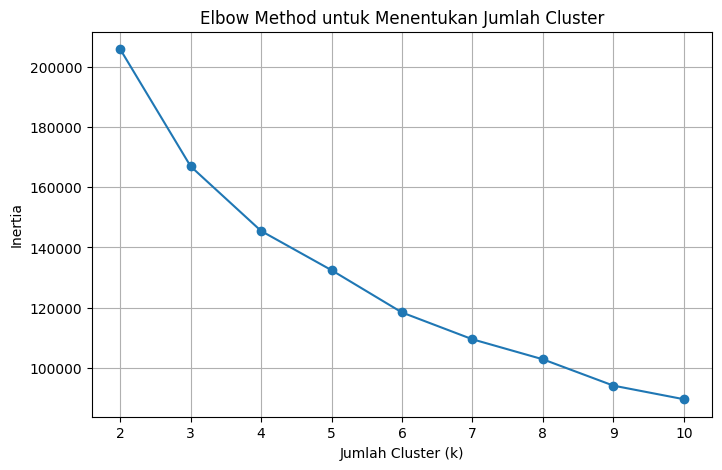

Silhouette Score untuk k=2: 0.246
Silhouette Score untuk k=3: 0.245
Silhouette Score untuk k=4: 0.236
Silhouette Score untuk k=5: 0.214
Silhouette Score untuk k=6: 0.226
Silhouette Score untuk k=7: 0.226
Silhouette Score untuk k=8: 0.222
Silhouette Score untuk k=9: 0.232
Silhouette Score untuk k=10: 0.220


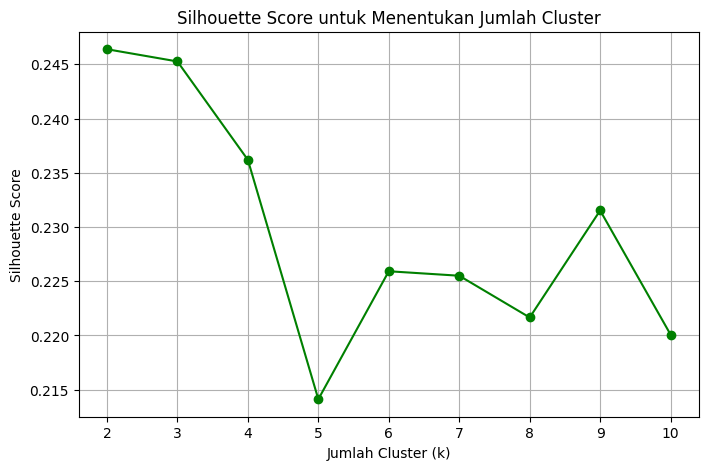

In [27]:
# Hitung inertia untuk berbagai jumlah cluster
inertia = []
k_range = range(2, 11)  # Mulai dari k=2 karena k=1 tidak bermakna untuk clustering
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(last_data)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')
plt.grid(True)
plt.show()

# Hitung Silhouette Score untuk berbagai jumlah cluster
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(last_data)
    score = silhouette_score(last_data, labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score untuk k={k}: {score:.3f}")

# Plot Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan Jumlah Cluster')
plt.grid(True)
plt.show()

Terlihat nilai silhoutte score yang begitu jelek, kita coba improve dengan PCA, di sini kita pakai reduksi dimensi 2

In [28]:
# Terapkan PCA
pca = PCA(n_components=2)  # Reduksi ke 2 dimensi
last_data_pca = pca.fit_transform(last_data)

# Ulang evaluasi dengan Silhouette Score
silhouette_scores_pca = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(last_data_pca)
    score = silhouette_score(last_data_pca, labels)
    silhouette_scores_pca.append(score)
    print(f"Silhouette Score (PCA) untuk k={k}: {score:.3f}")

Silhouette Score (PCA) untuk k=2: 0.384
Silhouette Score (PCA) untuk k=3: 0.404
Silhouette Score (PCA) untuk k=4: 0.367
Silhouette Score (PCA) untuk k=5: 0.375
Silhouette Score (PCA) untuk k=6: 0.335
Silhouette Score (PCA) untuk k=7: 0.332
Silhouette Score (PCA) untuk k=8: 0.336
Silhouette Score (PCA) untuk k=9: 0.344
Silhouette Score (PCA) untuk k=10: 0.339


Saya menyerah untuk improve nilai silhoutte, saya memutuskan menggunakan k = 3 karena memiliki silhoutte terbesar yaitu 0.404

## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

Setelah mengevaluasi jumlah cluster terbaik, kini saya akan melatih model dengan algoritma k-means (tidak dilakukan fitur seleksi)

In [38]:
# Latih K-Means dengan k=3
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(last_data_pca)

# Tambahkan label cluster ke DataFrame asli
last_data.loc[:, 'cluster'] = labels

# Tampilkan 5 baris pertama
last_data[['age', 'bmi', 'blood_glucose_level', 'hbA1c_level', 'cluster']].head()

,age,bmi,blood_glucose_level,hbA1c_level,cluster
0,-0.438444,-0.000116,-0.935040,-0.492966,1
1,-0.571723,-1.109805,-1.180648,-0.492966,0
2,-1.060410,-0.536139,0.538606,-0.679758,0
3,-0.038609,-0.000116,0.514045,-1.426928,1
4,0.450079,-0.537645,-1.180648,0.907978,2


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

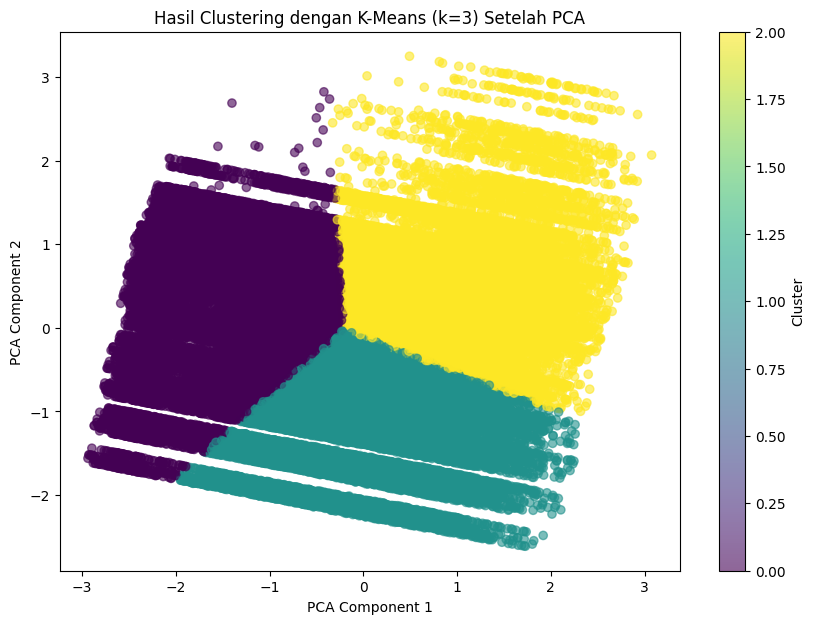

In [40]:
# Ubah last_data_pca menjadi DataFrame dengan 2 komponen PCA
last_data_pca_df = pd.DataFrame(last_data_pca, columns=['PC1', 'PC2'])
last_data_pca_df['cluster'] = labels

# Plot 2D
plt.figure(figsize=(10, 7))
scatter = plt.scatter(last_data_pca_df['PC1'], last_data_pca_df['PC2'], 
                      c=last_data_pca_df['cluster'], cmap='viridis', alpha=0.6)

# Label sumbu
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Hasil Clustering dengan K-Means (k=3) Setelah PCA')

# Tambahkan colorbar
plt.colorbar(scatter, label='Cluster')

# Tampilkan plot
plt.show()


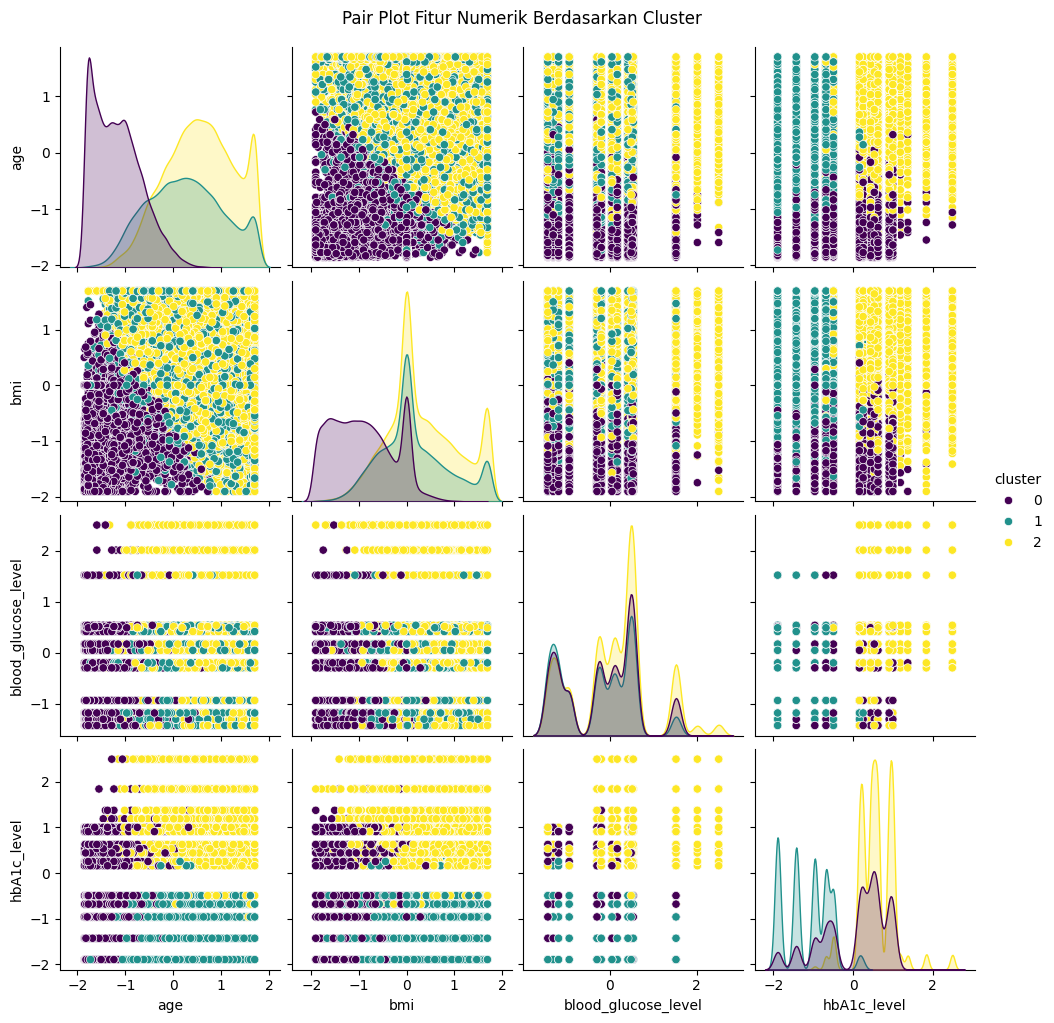

In [42]:
# Pair plot
sns.pairplot(last_data, vars=['age', 'bmi', 'blood_glucose_level', 'hbA1c_level'], hue='cluster', palette='viridis')
plt.suptitle('Pair Plot Fitur Numerik Berdasarkan Cluster', y=1.02)
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [46]:
# Ambil StandardScaler dari preprocessor
scaler = preprocessor.named_transformers_['num']

# Ambil fitur numerik yang distandarisasi dari last_data
numeric_data = last_data[numeric_features]

# Inverse transform untuk mengembalikan ke skala asli
numeric_data_original = scaler.inverse_transform(numeric_data)

# Buat DataFrame baru dengan nilai asli
last_data_df_original = pd.DataFrame(numeric_data_original, columns=numeric_features)

# Tambahkan kolom cluster
last_data_df_original['cluster'] = last_data['cluster'].values

# Tampilkan 5 baris pertama (sebelum inverse)
print("Sebelum inverse transform:")
print(last_data.head())

# Tampilkan 5 baris pertama (setelah inverse)
print("\nSetelah inverse transform:")
print(last_data_df_original.head())


Sebelum inverse transform:
        age       bmi  blood_glucose_level  hbA1c_level  cluster
0 -0.438444 -0.000116            -0.935040    -0.492966        1
1 -0.571723 -1.109805            -1.180648    -0.492966        0
2 -1.060410 -0.536139             0.538606    -0.679758        0
3 -0.038609 -0.000116             0.514045    -1.426928        1
4  0.450079 -0.537645            -1.180648     0.907978        2

Setelah inverse transform:
    age    bmi  blood_glucose_level  hbA1c_level  cluster
0  32.0  27.32                100.0          5.0        1
1  29.0  19.95                 90.0          5.0        0
2  18.0  23.76                160.0          4.8        0
3  41.0  27.32                159.0          4.0        1
4  52.0  23.75                 90.0          6.5        2


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

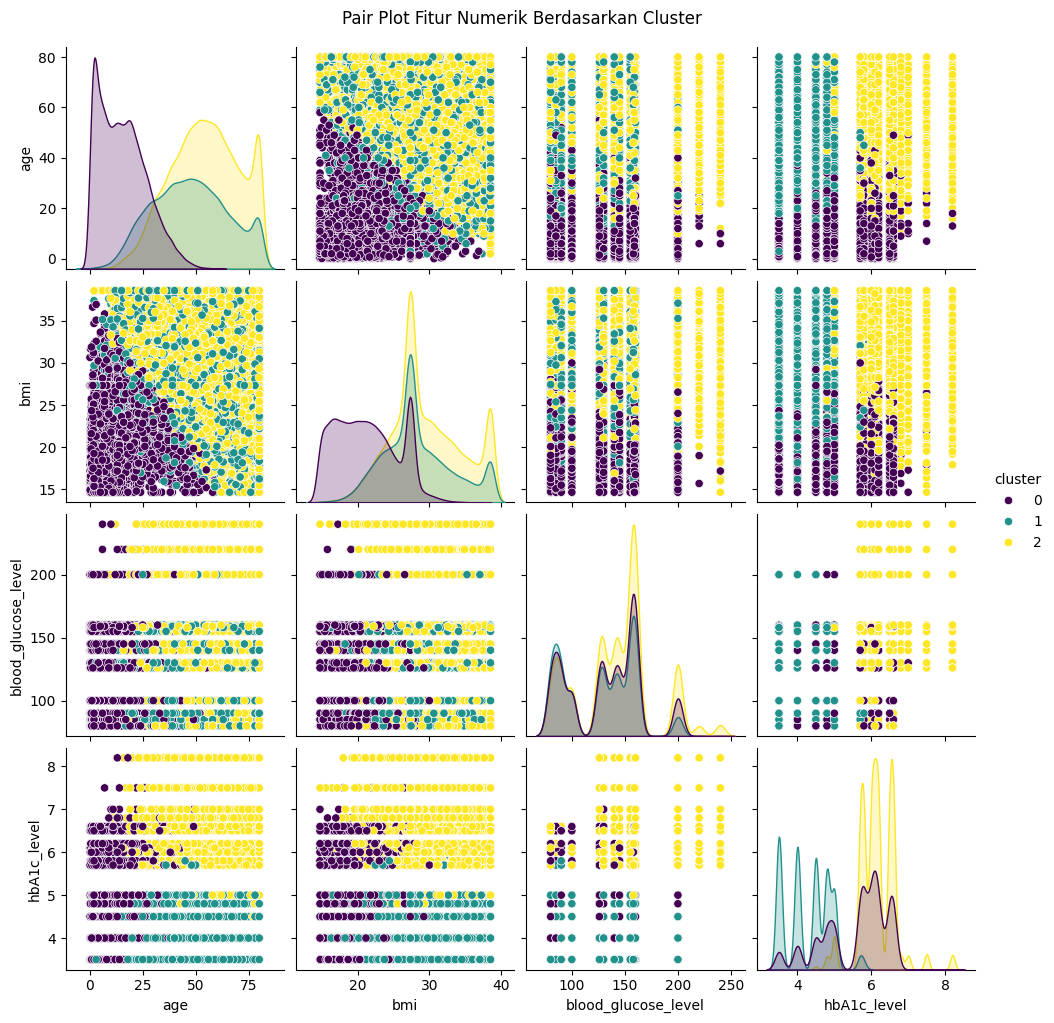

In [47]:
# Pair plot
sns.pairplot(last_data_df_original, vars=['age', 'bmi', 'blood_glucose_level', 'hbA1c_level'], hue='cluster', palette='viridis')
plt.suptitle('Pair Plot Fitur Numerik Berdasarkan Cluster', y=1.02)
plt.show()

In [52]:
# Hitung rata-rata setiap fitur numerik per cluster
mean_per_cluster = last_data_df_original.groupby('cluster')[['age', 'bmi', 'blood_glucose_level', 'hbA1c_level']].mean()

# Tampilkan hasil
print("Rata-rata setiap fitur per cluster:")
print(mean_per_cluster)

Rata-rata setiap fitur per cluster:
               age        bmi  blood_glucose_level  hbA1c_level
cluster                                                        
0        15.510499  21.250165           132.236151     5.581945
1        47.505166  28.342644           126.756606     4.308516
2        54.451450  29.485971           142.027253     6.153732


Saya akan membuat dulu list katogori dari masing-masing fitur:
- age (Umur)
Kategori:
0-18: "Anak"
19-40: "Dewasa Muda"
41-60: "Dewasa"
60: "Lansia"

- bmi (Body Mass Index)
Kategori (berdasarkan standar WHO):
<18.5: "Kurus"
18.5-24.9: "Ideal"
25-29.9: "Gemuk"
≥30: "Obesitas"

- blood_glucose_level (Kadar Gula Darah, mg/dL)
Kategori (berdasarkan kadar gula darah puasa):
<100: "Normal"
100-125: "Pra-diabetes"
≥126: "Diabetes"

- hbA1c_level (Hemoglobin A1c, %)
Kategori (berdasarkan pedoman diagnosis diabetes):
<5.7: "Normal"
5.7-6.4: "Pra-diabetes"
≥6.5: "Diabetes"

# Tulis hasil interpretasinya di sini.
## 1. Cluster 0: 
- rata-rata berumur 16 tahun dengan bmi kisaran 21, level gula darah 132, dan level hemoglobin A1c kisaran 5.58
- analisis: cluster ini diisi oleh yang anak-anak dengan badan yang ideal, terjangkit diabetes berdasarkan kadar gula darah, namun pra-diabetes secara hemoglobin (menurut saya lebih baik menggunakan hemoglobin sebagai acuan diabetes ketimbang kadar gula darah karena hemoglobin A1c (disingkat HbA1c), merupakan ukuran penting dalam dunia medis untuk menilai kadar gula darah rata-rata seseorang selama 2-3 bulan terakhir, sedangkan kadar gula darah diukur pada satu waktu), jadi cluster ini pra-diabetes
## 2. Cluster 1:
- rata-rata berumur 48 tahun dengan bmi kisaran 28, level gula darah 127, dan level hemoglobin A1c kisaran 4.31
- analisis: cluster ini diisi oleh yang orang dewasa dengan badan yang cendrung gemuk, terjangkit diabetes berdasarkan kadar gula darah, namun normal secara hemoglobin (menurut saya lebih baik menggunakan hemoglobin sebagai acuan diabetes ketimbang kadar gula darah karena hemoglobin A1c (disingkat HbA1c), merupakan ukuran penting dalam dunia medis untuk menilai kadar gula darah rata-rata seseorang selama 2-3 bulan terakhir, sedangkan kadar gula darah diukur pada satu waktu), jadi cluster ini normal
## 3. Cluster 2:
- rata-rata berumur 55 tahun dengan bmi kisaran 30, level gula darah 142, dan level hemoglobin A1c kisaran 6.15
- analisis: cluster ini diisi oleh yang orang dewasa dengan badan yang obesitas, terjangkit diabetes berdasarkan kadar gula darah, namun pra-diabetes secara hemoglobin (menurut saya lebih baik menggunakan hemoglobin sebagai acuan diabetes ketimbang kadar gula darah karena hemoglobin A1c (disingkat HbA1c), merupakan ukuran penting dalam dunia medis untuk menilai kadar gula darah rata-rata seseorang selama 2-3 bulan terakhir, sedangkan kadar gula darah diukur pada satu waktu), jadi cluster ini pra-diabetes

## Insight dari saya:
- Menurut saya, fitur yang paling menjadi acuan dalam cluster ini adalah bmi karena nilainya sangat terklasifikasi dengan baik. 
- Terlihat anak muda yang ideal lebih banyak terkena pra-diabetes ketimbang orang dewasa gemuk karena mereka cendrung normal. Hal ini mungkin terjadi karena pola makan anak-anak yang tidak sehat. Faktor gemuk di sini ternyata tidak signifikan mempengaruhi kadar gula seseorang, selagi belum mencapai obesitas.
- Cluster 1 dan 2 cendrung berusia dewasa namun bedanya yang satu gemuk dan yang satu lagi obesitas. Di sini dapat terlihat ketika seseorang mengalami obesitas, terjadi lonjakan kadar gula darah mereka. Ini juga mungkin disebabkan pola makan yang tidak sehat pada sebagian orang dewasa.
- Obesitas dapat mempengaruhi kadar gula darah secara signifikan, dapat dilihat dari perubahan cluster 0 dan 2 yang sebenarnya sama-sama pra-diabetes, tapi lebih besar pada cluster 2. Sebenarnya bisa juga dibuat hipotesis bahwa usia dewasa lebih berpeluang untuk terkena diabetes ketimbang anak-anak.
- Sepertinya ada tren bahwa semakin berumur maka berat badan seseorang semakin tidak ideal. Jadi semakin berumur, kita harus semakin menjaga pola makan agar tidak terkena obesitas maupun diabetes.

# Contoh interpretasi [TEMPLATE]
# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 1:
- **Rata-rata Annual Income (k$):** 48,260  
- **Rata-rata Spending Score (1-100):** 56.48  
- **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan menengah dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang moderat dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka.

## Cluster 2:
- **Rata-rata Annual Income (k$):** 86,540  
- **Rata-rata Spending Score (1-100):** 82.13  
- **Analisis:** Cluster ini menunjukkan pelanggan dengan pendapatan tahunan tinggi dan pengeluaran yang sangat tinggi. Pelanggan di cluster ini merupakan kelompok premium dengan daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar untuk produk atau layanan.

## Cluster 3:
- **Rata-rata Annual Income (k$):** 87,000  
- **Rata-rata Spending Score (1-100):** 18.63  
- **Analisis:** Cluster ini terdiri dari pelanggan dengan pendapatan tahunan yang tinggi tetapi pengeluaran yang rendah. Mereka mungkin memiliki kapasitas finansial yang baik namun tidak terlalu aktif dalam berbelanja. Ini bisa menunjukkan bahwa mereka lebih selektif dalam pengeluaran mereka atau mungkin lebih cenderung untuk menyimpan uang.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [54]:
# Simpan DataFrame dengan skala asli
last_data_df_original.to_csv('last_data_df_original_with_clusters.csv', index=False)
print("DataFrame dengan skala asli disimpan ke 'last_data_df_original_with_clusters.csv'")

DataFrame dengan skala asli disimpan ke 'last_data_df_original_with_clusters.csv'
